# Results Dashboard

Visualizes experiment results from the centralized `results/experiment_results.csv`.

This CSV is automatically populated by `graphium-train` after each run.
Each row = one training run with metadata and all test metrics.

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_CSV = Path('../results/experiment_results.csv')
df = pd.read_csv(RESULTS_CSV)
print(f"Loaded {len(df)} rows from {RESULTS_CSV}")

# Filter to gpspp_800M runs only (hidden_dim=1536, gnn_depth=12)
# to ensure fair comparison across pre-training datasets.
df = df[df['hidden_dim'] == 1536].reset_index(drop=True)
print(f"After filtering to gpspp_800M (hidden_dim=1536): {len(df)} rows")

Loaded 159 rows from ../results/experiment_results.csv
After filtering to gpspp_800M (hidden_dim=1536): 89 rows


## 1. Overview: runs by model and task

In [2]:
print("Runs by model type:")
print(df['model'].value_counts().to_string())
print()
print("Runs by task:")
print(df['task'].value_counts().to_string())
print()
df['is_finetuning'] = df['is_finetuning'].fillna(False).astype(bool)
print(f"Finetuned: {df['is_finetuning'].sum()} / Scratch: {(~df['is_finetuning']).sum()}")

Runs by model type:
model
pyg:gps    89

Runs by task:
task
caco2_wang                        4
hia_hou                           4
pgp_broccatelli                   4
bioavailability_ma                4
lipophilicity_astrazeneca         4
solubility_aqsoldb                4
bbb_martins                       4
ppbr_az                           4
vdss_lombardo                     4
cyp2d6_veith                      4
cyp3a4_veith                      4
cyp2c9_veith                      4
cyp2c9_substrate_carbonmangels    4
cyp2d6_substrate_carbonmangels    4
cyp3a4_substrate_carbonmangels    4
half_life_obach                   4
clearance_hepatocyte_az           4
clearance_microsome_az            4
ld50_zhu                          4
herg                              4
ames                              4
dili                              4
multitask                         1

Finetuned: 66 / Scratch: 23


## 2. Extract primary metric per task

Each ADMET task has a primary metric. We extract the test metric column for each task.

In [3]:
# TDC ADMET primary metrics (ordered by category as in the TDC paper)
# https://tdcommons.ai/benchmark/admet_group/overview/

# Canonical task ordering: Absorption -> Distribution -> Metabolism -> Excretion -> Toxicity
ADMET_TASK_ORDER = [
    # Absorption
    'caco2_wang', 'hia_hou', 'pgp_broccatelli', 'bioavailability_ma',
    'lipophilicity_astrazeneca', 'solubility_aqsoldb',
    # Distribution
    'bbb_martins', 'ppbr_az', 'vdss_lombardo',
    # Metabolism
    'cyp2d6_veith', 'cyp3a4_veith', 'cyp2c9_veith',
    'cyp2c9_substrate_carbonmangels', 'cyp2d6_substrate_carbonmangels', 'cyp3a4_substrate_carbonmangels',
    # Excretion
    'half_life_obach', 'clearance_hepatocyte_az', 'clearance_microsome_az',
    # Toxicity
    'ld50_zhu', 'herg', 'ames', 'dili',
]

TASK_CATEGORY = {}
for t in ADMET_TASK_ORDER[:6]:   TASK_CATEGORY[t] = 'Absorption'
for t in ADMET_TASK_ORDER[6:9]:  TASK_CATEGORY[t] = 'Distribution'
for t in ADMET_TASK_ORDER[9:15]: TASK_CATEGORY[t] = 'Metabolism'
for t in ADMET_TASK_ORDER[15:18]: TASK_CATEGORY[t] = 'Excretion'
for t in ADMET_TASK_ORDER[18:]:  TASK_CATEGORY[t] = 'Toxicity'

TASK_METRICS = {
    'caco2_wang': ('mae', 'lower'),
    'hia_hou': ('auroc', 'higher'),
    'pgp_broccatelli': ('auroc', 'higher'),
    'bioavailability_ma': ('auroc', 'higher'),
    'lipophilicity_astrazeneca': ('mae', 'lower'),
    'solubility_aqsoldb': ('mae', 'lower'),
    'bbb_martins': ('auroc', 'higher'),
    'ppbr_az': ('mae', 'lower'),
    'vdss_lombardo': ('spearman', 'higher'),
    'cyp2d6_veith': ('auprc', 'higher'),
    'cyp3a4_veith': ('auprc', 'higher'),
    'cyp2c9_veith': ('auprc', 'higher'),
    'cyp2c9_substrate_carbonmangels': ('auprc', 'higher'),
    'cyp2d6_substrate_carbonmangels': ('auprc', 'higher'),
    'cyp3a4_substrate_carbonmangels': ('auroc', 'higher'),
    'half_life_obach': ('spearman', 'higher'),
    'clearance_hepatocyte_az': ('spearman', 'higher'),
    'clearance_microsome_az': ('spearman', 'higher'),
    'ld50_zhu': ('mae', 'lower'),
    'herg': ('auroc', 'higher'),
    'ames': ('auroc', 'higher'),
    'dili': ('auroc', 'higher'),
}

def find_metric_column(df, task, metric_name):
    """Find the test metric column for a given task."""
    candidates = [c for c in df.columns if task in c.lower() and metric_name in c.lower() and 'test' in c.lower()]
    if candidates:
        return candidates[0]
    candidates = [c for c in df.columns if 'loss' in c.lower() and 'test' in c.lower()]
    return candidates[0] if candidates else None

def extract_primary_metric(row):
    """Extract the primary metric value for the task in this row."""
    task = row.get('task', '')
    if task not in TASK_METRICS:
        return np.nan
    metric_name, _ = TASK_METRICS[task]
    col = find_metric_column(df, task, metric_name)
    if col is None:
        return np.nan
    return row.get(col, np.nan)

df['primary_metric'] = df.apply(extract_primary_metric, axis=1)
df['metric_direction'] = df['task'].map(lambda t: TASK_METRICS.get(t, (None, None))[1])
df['metric_name'] = df['task'].map(lambda t: TASK_METRICS.get(t, (None, None))[0])
df['category'] = df['task'].map(TASK_CATEGORY)

print(f"Tasks with extracted metrics: {df['primary_metric'].notna().sum()} / {len(df)}")

Tasks with extracted metrics: 88 / 89


## 3. Dataset type ablation

Compare downstream ADMET performance across pre-training datasets.

In [4]:
def parse_pretrain_dataset(pretrain_model_path):
    """Infer the pre-training dataset from the checkpoint path."""
    s = str(pretrain_model_path).lower()
    if s == 'scratch' or s == 'nan':
        return 'scratch'
    for name, patterns in [
        ('largemix_rxrx3', ['largemix_rxrx3', 'largemixrxrx3', 'largemix-rxrx3']),
        ('largemix_dti',   ['largemix_dti', 'largemixdti', 'largemix-dti']),
        ('toymix_rxrx3',   ['toymix_rxrx3', 'toymixrxrx3', 'toymix-rxrx3']),
        ('toymix_dti',     ['toymix_dti', 'toymixdti', 'toymix-dti']),
        ('largemix',       ['largemix', 'large-dataset']),
        ('toymix',         ['toymix', 'small-dataset']),
        ('rxrx3',          ['rxrx3']),
        ('dti',            ['/dti/', '/dti-']),
    ]:
        if any(p in s for p in patterns):
            return name
    return 'unknown'

def parse_data_fraction(row):
    """Extract data fraction from W&B tags, or from known checkpoint mapping."""
    tags = str(row.get('wandb_tags', ''))
    match = re.search(r'frac_(\d+\.?\d*)', tags)
    if match:
        return float(match.group(1))
    KNOWN_FRACS = {
        '2026-03-18_14-53-57': 0.5,  # toymix 50%
    }
    pt = str(row.get('pretrain_dataset', ''))
    for ts, frac in KNOWN_FRACS.items():
        if ts in pt:
            return frac
    return 1.0

def build_method_label(row):
    """Create a human-readable method label for the results table."""
    ft = row.get('is_finetuning', False)
    pt = row.get('pretrain_type', 'scratch')
    frac = row.get('data_fraction', 1.0)
    frac_str = f' {frac:.0%}' if frac < 1.0 else ''
    if not ft and pt == 'scratch':
        return 'Scratch'
    if ft:
        return f'FT ({pt}{frac_str})'
    return pt

df['pretrain_type'] = df['pretrain_dataset'].apply(parse_pretrain_dataset)
df['primary_metric'] = pd.to_numeric(df['primary_metric'], errors='coerce')
df['data_fraction'] = df.apply(parse_data_fraction, axis=1)
df['method'] = df.apply(build_method_label, axis=1)

# Filter to ADMET tasks only
admet_df = df[df['task'].isin(TASK_METRICS.keys())].copy()

if len(admet_df) > 0 and admet_df['primary_metric'].notna().any():
    pivot = admet_df.pivot_table(
        index='task', columns='method', values='primary_metric', aggfunc='mean'
    )

    row_order = [t for t in ADMET_TASK_ORDER if t in pivot.index]
    pivot = pivot.loc[row_order]

    method_order = ['Scratch'] + sorted([c for c in pivot.columns if c.startswith('FT')])
    method_order += [c for c in pivot.columns if c not in method_order]
    pivot = pivot[[c for c in method_order if c in pivot.columns]]

    row_labels = []
    for task in pivot.index:
        metric_name, direction = TASK_METRICS.get(task, ('?', 'higher'))
        arrow = '\u2191' if direction == 'higher' else '\u2193'
        row_labels.append(f'{task}  ({metric_name} {arrow})')

    best_col_per_row = {}
    for task in pivot.index:
        direction = TASK_METRICS.get(task, (None, 'higher'))[1]
        row_vals = pivot.loc[task].dropna()
        if len(row_vals) > 0:
            best_col = row_vals.idxmin() if direction == 'lower' else row_vals.idxmax()
            best_col_per_row[task] = list(pivot.columns).index(best_col)

    # Compute category boundaries dynamically from actual tasks in the pivot
    category_boundaries = set()
    prev_cat = None
    for i, task in enumerate(pivot.index):
        cat = TASK_CATEGORY.get(task)
        if prev_cat is not None and cat != prev_cat:
            category_boundaries.add(i)
        prev_cat = cat

    display_pivot = pivot.copy()
    display_pivot.index = row_labels

    def highlight_best(row):
        task = pivot.index[display_pivot.index.get_loc(row.name)]
        styles = [''] * len(row)
        if task in best_col_per_row:
            j = best_col_per_row[task]
            styles[j] = 'font-weight: bold; color: #1a5fb4; text-decoration: underline'
        return styles

    def category_borders(row):
        idx = display_pivot.index.get_loc(row.name)
        if idx in category_boundaries:
            return ['border-top: 3px solid black'] * len(row)
        return [''] * len(row)

    styled = (
        display_pivot.style
        .format(precision=4, na_rep='')
        .apply(highlight_best, axis=1)
        .apply(category_borders, axis=1)
        .set_caption('ADMET Performance: Task x Method')
        .set_table_styles([
            {'selector': 'th', 'props': [('font-weight', 'bold')]},
            {'selector': 'td', 'props': [('text-align', 'center')]},
        ])
    )

    print("Primary metric per task x method:")
    print("(Ordered: Absorption -> Distribution -> Metabolism -> Excretion -> Toxicity)")
    print("Best per row: bold, blue, underlined")
    display(styled)
else:
    print("No ADMET results found yet. Run experiments first.")

Primary metric per task x method:
(Ordered: Absorption -> Distribution -> Metabolism -> Excretion -> Toxicity)
Best per row: bold, blue, underlined


method,Scratch,FT (rxrx3),FT (toymix 50%),FT (toymix)
caco2_wang (mae ↓),0.5648,1.2462,0.5781,0.5372
hia_hou (auroc ↑),0.5000,0.4988,0.8233,0.8333
pgp_broccatelli (auroc ↑),0.8214,0.4373,0.7704,0.8155
bioavailability_ma (auroc ↑),0.5000,0.5037,0.6611,0.6275
lipophilicity_astrazeneca (mae ↓),0.9721,0.9677,0.9686,0.9724
solubility_aqsoldb (mae ↓),1.0424,1.8897,1.5298,1.4957
bbb_martins (auroc ↑),0.7324,0.5569,0.7237,0.7342
ppbr_az (mae ↓),81.4208,17.4642,12.8629,13.3702
vdss_lombardo (spearman ↑),0.4539,0.0541,0.1293,0.2426
cyp2d6_veith (auprc ↑),0.1766,0.1488,0.3480,0.2968


## 4. Aggregate comparison: scratch vs pre-trained

Bar chart comparing mean normalized performance.

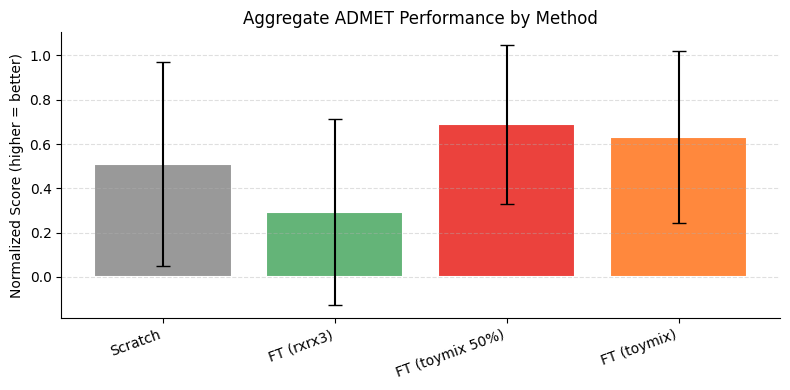

In [5]:
if len(admet_df) > 0 and admet_df['primary_metric'].notna().any():
    admet_df = admet_df.copy()
    
    # Normalize within each task: map metric to [0, 1] where 1 = best
    scores = []
    for task, group in admet_df.groupby('task'):
        direction = TASK_METRICS.get(task, (None, 'higher'))[1]
        vals = group['primary_metric'].astype(float)
        if direction == 'lower':
            vals = -vals
        vmin, vmax = vals.min(), vals.max()
        if vmax == vmin:
            norm = pd.Series(0.5, index=group.index)
        else:
            norm = (vals - vmin) / (vmax - vmin)
        scores.append(norm)
    admet_df['normalized_score'] = pd.concat(scores).astype(float)
    
    agg = admet_df.groupby('method')['normalized_score'].agg(['mean', 'std', 'count'])
    # Order: Scratch first, then FT variants alphabetically
    order = ['Scratch'] + sorted([c for c in agg.index if c.startswith('FT')])
    order += [c for c in agg.index if c not in order]
    agg = agg.loc[[c for c in order if c in agg.index]]
    
    fig, ax = plt.subplots(figsize=(max(8, len(agg)*1.5), 4))
    palette = {'Scratch': '#999999'}
    ft_colors = ['#466eff', '#64B478', '#EB423D', '#FF883D', '#9B59B6']
    for i, m in enumerate(agg.index):
        if m not in palette:
            palette[m] = ft_colors[i % len(ft_colors)]
    colors = [palette.get(m, '#466eff') for m in agg.index]
    
    bars = ax.bar(range(len(agg)), agg['mean'], yerr=agg['std'],
                  color=colors, capsize=5, edgecolor='white', linewidth=1.5)
    ax.set_xticks(range(len(agg)))
    ax.set_xticklabels(agg.index, rotation=20, ha='right')
    ax.set_ylabel('Normalized Score (higher = better)')
    ax.set_title('Aggregate ADMET Performance by Method')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, axis='y', ls='--', alpha=0.4)
    
    # for i, (bar, count) in enumerate(zip(bars, agg['count'])):
    #     ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
    #             f'n={int(count)}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()
else:
    print("No ADMET results to aggregate.")

## 5. Per-task detail table

Full results table with all metrics for export.

In [6]:
if len(admet_df) > 0:
    summary = admet_df[['task', 'category', 'method', 'metric_name', 'primary_metric']].copy()
    summary['primary_metric'] = summary['primary_metric'].round(4)
    task_order_map = {t: i for i, t in enumerate(ADMET_TASK_ORDER)}
    summary['_order'] = summary['task'].map(task_order_map)
    summary = summary.sort_values(['_order', 'method']).drop(columns='_order').reset_index(drop=True)
    display(summary)
    
    export_path = Path('../results/summary_table.csv')
    summary.to_csv(export_path, index=False)
    print(f"\nExported summary to {export_path}")

,task,category,method,metric_name,primary_metric
0,caco2_wang,Absorption,FT (rxrx3),mae,1.2462
1,caco2_wang,Absorption,FT (toymix 50%),mae,0.5781
2,caco2_wang,Absorption,FT (toymix),mae,0.5372
3,caco2_wang,Absorption,Scratch,mae,0.5648
4,hia_hou,Absorption,FT (rxrx3),auroc,0.4988
...,...,...,...,...,...
83,ames,Toxicity,Scratch,auroc,0.6933
84,dili,Toxicity,FT (rxrx3),auroc,0.6757
85,dili,Toxicity,FT (toymix 50%),auroc,0.7939
86,dili,Toxicity,FT (toymix),auroc,0.6980



Exported summary to ../results/summary_table.csv
